# **0.Import**

In [1]:
import sys 
import os

sys.path.append(os.path.abspath('..'))
from transformers import AutoImageProcessor
import torch
import torch.nn as nn
from torchvision import models
from lib.data.dataset import BeeDataset
from lib.data.preprocessing import TorchPreprocessor
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from lib.data.train_val_split import train_val_split
from lib.data.data_augmentation import data_augmented_loader
import torch.nn.functional as F


# **1. Hypèreparamètre**

In [ ]:
batch_size = 32

num_classes = 50

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr= 0.01
epochs = 20
weight_decay = 0.00001

dropout = 0.25

# **2. Prèprocessing**

In [3]:

#### Param du resnet #####
resnet_processor_parameters = {
    "mean": [0.485, 0.456, 0.406],
    "std": [0.229, 0.224, 0.225],
    "crop_size": (224, 224)
}




train_preprocessor_light = TorchPreprocessor (mean = resnet_processor_parameters["mean"], 
                                              std = resnet_processor_parameters["std"], 
                                              normalize = True,
                                              augmentation = 'light', 
                                              resize_method = 'crop', 
                                              interpolation_method = 'BICUBIC', 
                                              resize_value = 256, 
                                              target_size = (224,224)) 

train_preprocessor_heavy = TorchPreprocessor (mean = resnet_processor_parameters["mean"], 
                                              std = resnet_processor_parameters["std"], 
                                              normalize = True,
                                              augmentation = 'heavy', 
                                              resize_method = 'crop', 
                                              interpolation_method = 'BICUBIC', 
                                              resize_value = 256, 
                                              target_size = (224,224)) 


val_preprocessor = TorchPreprocessor (mean = resnet_processor_parameters["mean"], 
                                      std = resnet_processor_parameters["std"], 
                                      normalize = True,
                                      augmentation = 'None', 
                                      resize_method = 'crop', 
                                      interpolation_method = 'BICUBIC', 
                                      resize_value = 256, 
                                      target_size = (224,224)) 


##### Param du efficientnet #####
model_name = "google/efficientnet-b3"

base_processor = AutoImageProcessor.from_pretrained(model_name)

efficientnet_processor_parameters= {
    "mean" : base_processor.image_mean,
    "std" : base_processor.image_std,
    "crop_size" : (base_processor.size["height"], base_processor.size["width"])
}



The image processor of type `EfficientNetImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [4]:
# root_dir = '../data/train'
# # transforme = TorchPreprocessor(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# # dataset = BeeDataset(train= True, transform = transforme)

# train_dataset, val_dataset = train_val_split(transforme)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


####### Preproceseur pour le test ######

transforme = TorchPreprocessor(
    normalize=True,
    mean=resnet_processor_parameters["mean"],
    std=resnet_processor_parameters["std"],
    resize_method="pad",      # ou "resize" selon ton pipeline
    target_size=resnet_processor_parameters["crop_size"],
)


####### Creation des dataloader #####

train_loader, val_loader = data_augmented_loader(mean=resnet_processor_parameters["mean"],
    std=resnet_processor_parameters["std"], target_size=(224,224), train_preprocessor_light = train_preprocessor_light, 
    train_preprocessor_heavy = train_preprocessor_heavy, val_preprocessor=val_preprocessor)


# n_total = len(dataset)

# n_train = int(0.80 * n_total)
# n_test = int(0.15 * n_total)
# n_val =  int(n_total - n_train - n_test)
# train_dataset, test_dataset, val_dataset = torch.utils.data.random_split(
#     dataset,
#     [n_train, n_test, n_val],
#     generator=torch.Generator().manual_seed(42)

# )


# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

# dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

Train prêt : 6417 images (avec augmentation ciblée)
Val prête  : 1582 images (sans augmentation)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            if not isinstance(alpha, torch.Tensor):
                alpha = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss).clamp(min=1e-8, max=1.0)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha = self.alpha.to(targets.device) 
            alpha = alpha[targets]
            focal_loss = alpha * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [ ]:
train_labels = [int(sample[1]) for sample in  train_loader.dataset]

In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

def compute_alpha(train_labels, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=train_labels
    )
    # Normaliser entre 0 et 1
    weights = weights / weights.sum() * num_classes
    return torch.tensor(weights, dtype=torch.float32)

alpha = compute_alpha(train_labels, num_classes=50)

# **3. Modèles**

In [5]:
class ResnetFineTune (nn.Module):
    def __init__(self, num_classes):
        super(ResnetFineTune, self).__init__()

        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
           
        for param in self.resnet.parameters():
            param.requires_grad = False

        for param in self.resnet.layer4.parameters():
            param.requires_grad = True

        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, num_classes),
            nn.Dropout(dropout)
        )

    def forward (self, x):
        

        return self.resnet(x)
    
    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        
        return pred_class

In [ ]:
class EfficientnetFineTune (nn.Module):
    def __init__(self, num_classes):
        super(EfficientnetFineTune, self).__init__()

        # self.model = models.efficientnet_b3(weights="IMAGENET1K_V1")
        self.model = models.efficientnet_v2_s(weights="IMAGENET1K_V1")

        # Geler les couches de base (optionnel — à décommenter si peu de données)
        for param in self.model.features.parameters():
            param.requires_grad = False

        # Remplacer la tête de classification
        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes),
        )

    def forward (self, x):
        

        return self.model(x)
    
    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        
        return pred_class

In [7]:
class WideResNet101FineTune(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.wide_resnet101_2(weights=models.Wide_ResNet101_2_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        for param in self.model.layer4.parameters():
            param.requires_grad = True

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1)
        return pred_class

In [8]:
class InceptionV3FineTune(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.inception_v3(weights=models.Inception_V3_Weights.DEFAULT, aux_logits=False)

        for param in self.model.parameters():
            param.requires_grad = False

        # Dé-geler dernier bloc
        for param in self.model.Mixed_7c.parameters():  # dernier bloc
            param.requires_grad = True

        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        # InceptionV3 attend des images >= 299x299
        return self.model(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1)
        return pred_class

In [9]:
class MnasNetA1FineTune(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.mnasnet1_0(weights=models.MNASNet1_0_Weights.DEFAULT)

        for param in self.model.parameters():
            param.requires_grad = False

        # Dé-geler le dernier bloc (features[-1])
        for param in self.model.layers[-1].parameters():
            param.requires_grad = True

        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1)
        return pred_class 

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class ViTFineTune(nn.Module):
    def __init__(self, num_classes):
        super(ViTFineTune, self).__init__()

        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)

        for param in self.vit.parameters():
            param.requires_grad = False

        for param in self.vit.encoder.layers[-2:].parameters():
            param.requires_grad = True

        in_features = self.vit.heads.head.in_features
        # self.vit.heads.head = nn.Linear(in_features, num_classes)
        self.vit.heads.head = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, num_classes),
        )

    def forward(self, x):
        return self.vit(x)

    def inference(self, x):
        self.eval()
        with torch.no_grad():
            logits = self(x)
            probs = torch.softmax(logits, dim=1)
            pred_class = torch.argmax(probs, dim=1).item()
        return pred_class

# **4. Entrainement**

In [11]:
class EarlyStopping:
    
    def __init__(self, patience=5, delta=0):
        self.patience = patience
        self.counter = 0
        self.best_score = None
        self.delta = delta
        self.early_stop = False

    def step(self, val_loss):
        """Step of the early stopping monitoring when to stop depending on the loss and the patience
        
        Args:
            val_loss (float) : loss value of the validation set at the epoch
        """
        
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            print('EarlyStopping counter: %d / %d' % (self.counter, self.patience))
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0

gadrer le meilleur modèle + warmup époch (faire que sur les 5 première époque le lr sois petitet augmente jusuq'a celui qu'on veut au bout de 5 époch).

K fold car dans notre validation il y a pas forcément la meme proportion des classe que dans le teste et vu que le leaderbord c'est  que la moitier ca peut être pas bon car on voit pas assez bien notre teste avec la validation

In [12]:
class DiceLoss(nn.Module):
    """
    Dice Loss for binary segmentation
    Works with model output (probabilities after Sigmoid)
    """

    def __init__(self, smooth=1e-7):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        """
        Args:
            pred: (B, 1, H, W) probabilities after sigmoid [0, 1]
            target: (B, 1, H, W) binary ground truth masks
        """
        probs = torch.softmax(pred, dim=1)
        targets_oh = F.one_hot(target, num_classes=probs.shape[1]).float()

        intersection = (probs * targets_oh).sum(dim=0)
        union = probs.sum(dim=0) + targets_oh.sum(dim=0)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice.mean()

In [13]:
# def dice_loss_multiclass(pred, target, smooth=1.0):


In [ ]:
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import f1_score

def training_CTC(device, lr, epochs, weight_decay, train_loader, val_loader, num_classes):
    """
    Training of our model using CrossEntropy loss with tqdm and F1-score per epoch.

    Args:
        device (torch.device) : cpu or gpu
        lr (float) : learning rate of the optimizer
        epochs (int) : number of epochs
        weight_decay (float) : weight decay for optimizer
        train_loader (DataLoader) : dataloader of the training data
        num_classes (int) : number of output classes

    Returns:
        model (nn.Module) : trained model
        loss_train (list) : training loss per epoch
        f1_train_list (list) : F1-score per epoch
    """

    # Initialisation of the model, loss function and optimiser
    model = ViTFineTune(num_classes).to(device)
    # model = ResnetFineTune(num_classes).to(device)
    # model = EfficientnetFineTune(num_classes).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    # criterion = DiceLoss()

    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer,
    #     mode='min',        
    #     factor=0.5,         
    #     patience=3
    # )

    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    #     optimizer,
    #     T_max=epochs,
    #     eta_min=1e-6
    # )

    best_f1 = 0.0
    best_model_state = None

    loss_train, loss_val = [], []
    f1_train_list = []

    for epoch in range(1, epochs + 1):
        model.train()
        temp_loss = []
        all_preds = []
        all_labels = []

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False)
        for X_batch, labels in loop:
            labels = labels.long().to(device)
            X_batch = X_batch.float().to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)

            loss = criterion(y_pred, labels)
            loss.backward()
            optimizer.step()

            temp_loss.append(loss.item())
            
            # Update tqdm description with current loss
            loop.set_postfix(loss=np.mean(temp_loss))

               
        avg_loss = np.mean(temp_loss)
        loss_train.append(avg_loss)

        model.eval()
        with torch.no_grad():
            
            temp_loss_val = []
            for X_val, labels_val in val_loader:


                labels_val = labels_val.long().to(device)
                X_val = X_val.float().to(device)
                y_val = model(X_val).to(device) #Prediction des positions

                val_loss = criterion(y_val, labels_val) #Calcule de la fonction de perte



                temp_loss_val.append(val_loss.cpu().detach().numpy())
                    
                # Collect predictions for F1
                preds = torch.argmax(y_val, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels_val.cpu().numpy())

        avg_val_loss = np.mean(np.array(temp_loss_val))

        loss_val.append(avg_val_loss) # At each epoch, we add the mean loss of all the validation data

        # scheduler.step(avg_val_loss)
            



        # Compute F1-score for the epoch
        f1_epoch = f1_score(all_labels, all_preds, average='macro')
        f1_train_list.append(f1_epoch)

        if f1_epoch > best_f1:
            best_f1 = f1_epoch
            best_model_state = model.state_dict().copy()

        print(f"Epoch {epoch}/{epochs} - Loss: {avg_loss:.4f} - Val Loss: {loss_val[-1]:.4f} - F1: {f1_epoch:.4f}")
        # scheduler.step()
    # Load the best model state
    model.load_state_dict(best_model_state)


    return model, loss_train, loss_val,  f1_train_list

In [15]:
# model, loss_train, loss_val = training_CTC(device, lr, epochs, weight_decay, train_loader, train_loader, earlystopping = False)
model, loss_train, loss_val, f1_train_list = training_CTC(device, lr, epochs, weight_decay, train_loader, val_loader, num_classes)

Epoch 1/20 - Loss: 1.8907 - Val Loss: 1.5552 - F1: 0.4566


Epoch 2/20 - Loss: 0.6590 - Val Loss: 1.1888 - F1: 0.5364


Epoch 3/20 - Loss: 0.4510 - Val Loss: 1.0455 - F1: 0.5813


Epoch 4/20 - Loss: 0.3253 - Val Loss: 1.0067 - F1: 0.5975


Epoch 5/20 - Loss: 0.2780 - Val Loss: 1.0029 - F1: 0.5691


...

Epoch 16/20 - Loss: 0.0815 - Val Loss: 0.8999 - F1: 0.6245


Epoch 17/20 - Loss: 0.0776 - Val Loss: 0.9830 - F1: 0.6369


Epoch 18/20 - Loss: 0.0750 - Val Loss: 0.8619 - F1: 0.6162


Epoch 19/20 - Loss: 0.0706 - Val Loss: 0.9280 - F1: 0.6098


Epoch 20/20 - Loss: 0.0615 - Val Loss: 1.0255 - F1: 0.6077


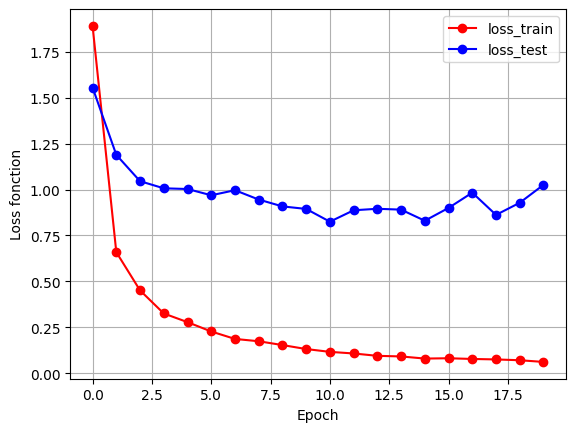

In [16]:
plt.plot(loss_train, 'r' , marker='o', linestyle='-', label = 'loss_train')
plt.plot(loss_val, 'b' , marker='o', linestyle='-', label = 'loss_test')
plt.xlabel('Epoch')
plt.ylabel('Loss fonction')
plt.grid()
plt.legend()
plt.show()

Enregistrement

In [17]:
# Put the model in eval mode
model = model.cpu().eval()

# Script the model
scripted_model = torch.jit.script(model)

# Save
scripted_model.save("model_vit_20.pt")

# **5. Submission**

In [18]:
def submission(model, X_test):
    pred = []
    for img in X_test:

        img = img[0].unsqueeze(0).to(device)  
        pred.append(model.to(device).inference(img))

    df = pd.DataFrame({
        "id": range(len(pred)),
        "label": pred
    })

    df.to_csv("submission3.csv", index=False)




In [19]:
test_dataset = BeeDataset(train = False, transform = transforme)

In [20]:
submission(model, test_dataset)

# Regarder Dice et MulticlassFocalLoss mais aussi adamW

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            if not isinstance(alpha, torch.Tensor):
                alpha = torch.tensor(alpha, dtype=torch.float32)
            self.register_buffer('alpha', alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss).clamp(min=1e-8, max=1.0)
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha = self.alpha[targets]
            focal_loss = alpha * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [ ]:
class_weights = compute_class_weight('balanced', classes=np.arange(50), y=train_labels)
weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

In [ ]:
def unfreeze_progressive(model, epoch):
    if epoch == 5:
        # Dégeler les derniers blocs features
        for param in model.model.features[6:].parameters():
            param.requires_grad = True
    if epoch == 10:
        # Tout dégeler
        for param in model.model.features.parameters():
            param.requires_grad = True

In [ ]:
# C'est la cellule “2. Modèle” entière
 
from torch.optim.lr_scheduler import CosineAnnealingLR


 
def create_model(num_classes: int) -> nn.Module:


 
    model = models.efficientnet_b0(weights="IMAGENET1K_V1") #mettre b3 si ca marche
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model


 
model = create_model(num_classes)
model.to(DEVICE)


 
criterion = nn.CrossEntropyLoss()


 
# --- Variante ---
# pip install torchmetrics
# from torchmetrics.classification import MulticlassFocalLoss
# criterion = MulticlassFocalLoss(num_classes=num_classes, alpha=0.25, gamma=2.0)


 
# FocalLoss peut être redondante avec l'utilisation d'un WeightedRandomSampler
# Label Smoothing dans la CrossEntropyLoss ? A 0.1 par exemple


 
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)


 
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)


 
# Usage de OneCycleLR
# steps_per_epoch = len(train_loader)


 
# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=LR,
#     steps_per_epoch=steps_per_epoch,
#     epochs=EPOCHS,
#     pct_start=0.1, # 10% du temps d'entraînement sera dédié au Warm-up (montée douce du LR)
#     div_factor=10.0, # Le LR commence à LR / 10
#     final_div_factor=100.0 # Le LR finit très bas
# )